In [1]:
from rdkit import Chem
from collections import Counter
from src import MoleculeRenderer


def draw_mol(mol, title="", highlight_atoms=None, highlight_bonds=None, display_props=None):
    mr = MoleculeRenderer()
    display(mr.render_2d(mol, title, highlight_atoms, highlight_bonds, display_props))


In [2]:
def freeze_original_index(mol):
    for i, atom in enumerate(mol.GetAtoms()):
        atom.SetProp("original_index", str(i))  # Зафриженный исходный индекс

In [3]:
# Затем сохраняем индексы соседей
def neibors_index_atoms(mol):
    for atom in mol.GetAtoms():
        neighbor_indices = []
        for neighbor in atom.GetNeighbors():
            neighbor_indices.append(str(neighbor.GetIdx()))
 # Сохраняем как строку с разделителем
        atom.SetProp("neighbor_indices", ",".join(neighbor_indices))


In [4]:
def calculate_neighbors_sum(mol):
    for atom in mol.GetAtoms():
        neighbor_count = len(atom.GetNeighbors())
        atom.SetProp("sum", str(neighbor_count))  # Сохраняем количество соседей

In [5]:
def calculate_next_sum(mol):
    # Сначала вычисляем next_sum для каждого атома
    for atom in mol.GetAtoms():
        neighbors_sum = 0
        for neighbor in atom.GetNeighbors():
            neighbors_sum += int(neighbor.GetProp("sum"))
        atom.SetProp("next_sum", str(neighbors_sum))
    
    # Затем заменяем sum на next_sum
    for atom in mol.GetAtoms():
        atom.SetProp("sum", atom.GetProp("next_sum"))
        atom.ClearProp("next_sum")  # Очищаем временное свойство

In [6]:
def get_group_count(mol):
    unique_sums = set()
    for atom in mol.GetAtoms():
        unique_sums.add(atom.GetProp("sum"))
    return unique_sums

In [7]:
def is_max_unique(arr):
    if not arr:
        return False
    counter = Counter(arr)
    max_value = max(arr)
    return counter[max_value] == 1

In [8]:

def make_sum_step(k_current, mock_molecule):
    calculate_next_sum(mock_molecule)
    groups = get_group_count(mock_molecule)
    k_current = len(groups)
    print(groups, k_current)
    largest_is_uniq = is_max_unique(groups) 
    return k_current, largest_is_uniq


10
{'6', '7', '3', '2', '4'} 5
{'6', '16', '9', '7', '17', '4', '13'} 7
{'16', '9', '21', '17', '33', '35', '40', '39'} 8
{'94', '74', '96', '21', '48', '35', '91', '40', '89'} 9
{'96', '218', '200', '183', '48', '91', '225', '89', '115'} 9


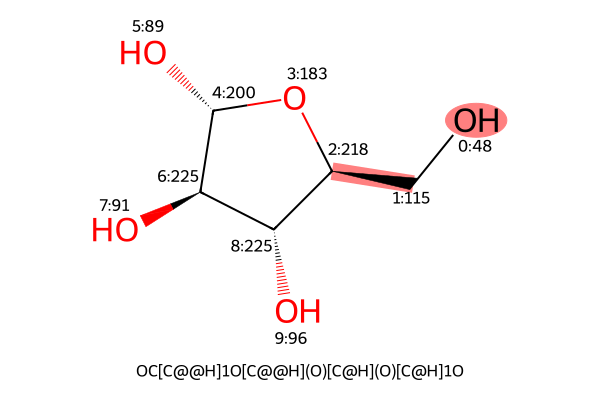

2D рендеринг выполнен


In [13]:
 
def test_molecule_renderer():
    mol = 'OC[C@@H]1O[C@@H](O)[C@H](O)[C@H]1O'
    # calculate_original_index(mol)
    mock_molecule = Chem.MolFromSmiles(mol)
    freeze_original_index(mock_molecule)
    neibors_index_atoms(mock_molecule)
    calculate_neighbors_sum(mock_molecule)
    all_atoms_count = len(mock_molecule.GetAtoms())
    print(all_atoms_count)
    k_current=0
    k_current_last = 0
   
    k_current,largest_is_uniq = make_sum_step(k_current, mock_molecule)
 
       
    while True:
        # код, который должен выполниться хотя бы один раз
         k_current,largest_is_uniq = make_sum_step(k_current, mock_molecule)
         if (largest_is_uniq and k_current_last == k_current) or k_current >= all_atoms_count :
            break
         k_current_last = k_current
    #     
    # make_morgan_indexes(mock_molecule)
    highlight_atoms = [0]
    highlight_bounds = [1]
    # Тест 2D рендеринга
    display_props=[ "sum" ]
    render_2d = draw_mol(mock_molecule, mol, highlight_atoms, highlight_bounds, display_props)
    
    return render_2d



test_molecule_renderer()
print("2D рендеринг выполнен")